In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [3]:
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
import os

print("Libraries loaded successfully for Multi-Market BESS Optimization!")

Libraries loaded successfully for Multi-Market BESS Optimization!


In [4]:
# Set up time horizon (24 hours ahead)
T = list(range(24))

np.random.seed(42)

# Synthetic Day-Ahead Electricity Prices (€/MWh) with realistic peak and off-peak behavior
da_prices = 50 + 25 * np.sin(2 * np.pi * np.array(T) / 24) + np.random.normal(0, 5, 24)
da_prices[17:21] += 45 # Evening peak price spike

# Synthetic aFRR Capacity Reservation Prices (€/MW-h)
afrr_prices = 15 + 8 * np.cos(2 * np.pi * np.array(T) / 24) + np.random.uniform(2, 5, 24)

# Synthetic Available Solar / Renewable Generation Profile (MW)
solar_profile = np.maximum(0, 3.0 * np.sin(np.pi * (np.array(T) - 6) / 12))
solar_profile[0:6] = 0
solar_profile[19:] = 0

print("Market price profiles and renewable generation data generated successfully.")

Market price profiles and renewable generation data generated successfully.


In [5]:
# Battery Technical Parameters
bess_power = 2.0  # Max Power (MW)
bess_energy = 6.0 # Max Energy Capacity (MWh)
initial_soc = 3.0 # Initial State of Charge (MWh)
eta = 0.95        # Round-trip efficiency factor

# Initialize PuLP Optimization Problem
model = pulp.LpProblem("Multi_Market_Revenue_Stacking", pulp.LpMaximize)

# Decision Variables for each hour t in T
P_charge = pulp.LpVariable.dicts("P_charge", T, lowBound=0.0, upBound=bess_power, cat='Continuous')
P_discharge = pulp.LpVariable.dicts("P_discharge", T, lowBound=0.0, upBound=bess_power, cat='Continuous')
R_afrr = pulp.LpVariable.dicts("R_afrr", T, lowBound=0.0, upBound=bess_power, cat='Continuous') # Reserved capacity for aFRR
SOC = pulp.LpVariable.dicts("SOC", T, lowBound=0.5, upBound=bess_energy, cat='Continuous')
u_charge = pulp.LpVariable.dicts("u_charge", T, cat='Binary')
u_discharge = pulp.LpVariable.dicts("u_discharge", T, cat='Binary')

# Objective Function: Maximize (Day-Ahead Arbitrage Revenue + aFRR Capacity Revenue - Degradation Cost)
revenue_da = pulp.lpSum([(solar_profile[t] + P_discharge[t] - P_charge[t]) * da_prices[t] for t in T])
revenue_afrr = pulp.lpSum([R_afrr[t] * afrr_prices[t] for t in T])
degradation_cost = pulp.lpSum([(P_charge[t] + P_discharge[t] + R_afrr[t]) * 1.2 for t in T])

model += revenue_da + revenue_afrr - degradation_cost

# Initial State of Charge Constraint
model += SOC[0] == initial_soc

# Operational Constraints
for t in T:
    # Mutual exclusivity between charging and discharging
    model += u_charge[t] + u_discharge[t] <= 1
    model += P_charge[t] <= bess_power * u_charge[t]
    model += P_discharge[t] <= bess_power * u_discharge[t]

    # Power capacity headroom for co-located aFRR and energy dispatch
    model += P_charge[t] + R_afrr[t] <= bess_power
    model += P_discharge[t] + R_afrr[t] <= bess_power

    # Battery State of Charge (SOC) transition dynamics
    if t > 0:
        model += SOC[t] == SOC[t-1] + (eta * P_charge[t] - (1.0 / eta) * P_discharge[t])

# Solve the Optimization Model
model.solve(pulp.PULP_CBC_CMD(msg=False))

print(f"Optimization Status: {pulp.LpStatus[model.status]}")
print(f"Total Optimal Co-optimized Daily Revenue: €{pulp.value(model.objective):,.2f}")

Optimization Status: Optimal
Total Optimal Co-optimized Daily Revenue: €2,191.62


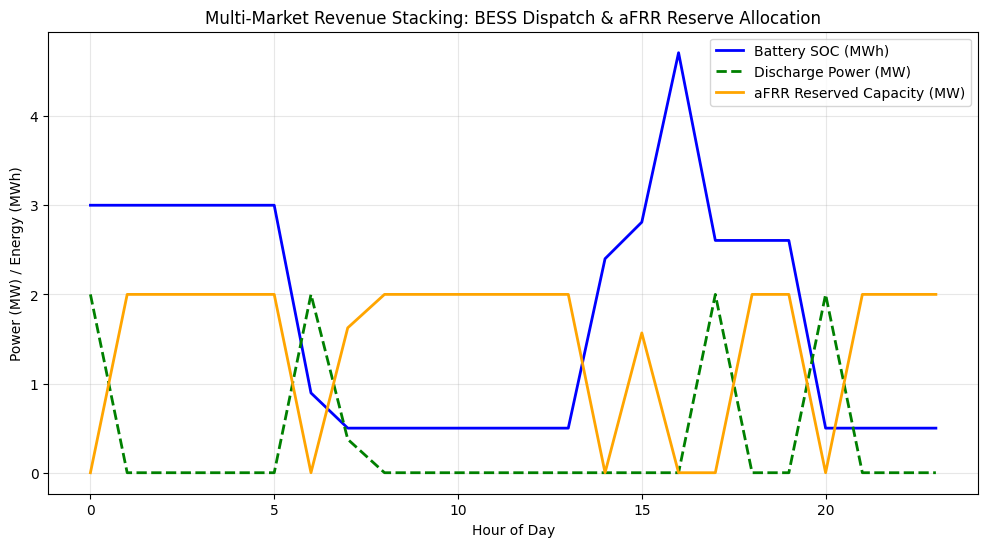

Reports and charts successfully saved in the 'outputs/' directory!


In [6]:
import os

# Create output directory
os.makedirs("outputs", exist_ok=True)

# Extract optimization results into a DataFrame
results = []
for t in T:
    results.append({
        'hour': t,
        'da_price_eur': da_prices[t],
        'afrr_price_eur': afrr_prices[t],
        'solar_mw': solar_profile[t],
        'charge_mw': pulp.value(P_charge[t]),
        'discharge_mw': pulp.value(P_discharge[t]),
        'afrr_mw': pulp.value(R_afrr[t]),
        'soc_mwh': pulp.value(SOC[t])
    })

df_results = pd.DataFrame(results)

# Save tabular reports to CSV and Excel
df_results.to_csv("outputs/multi_market_dispatch_report.csv", index=False)
df_results.to_excel("outputs/multi_market_dispatch_report.xlsx", index=False)

# Plotting Operational Dispatch & Revenue Stacking Profile
plt.figure(figsize=(12, 6))
plt.plot(df_results['hour'], df_results['soc_mwh'], label='Battery SOC (MWh)', color='blue', linewidth=2)
plt.plot(df_results['hour'], df_results['discharge_mw'], label='Discharge Power (MW)', color='green', linestyle='--', linewidth=2)
plt.plot(df_results['hour'], df_results['afrr_mw'], label='aFRR Reserved Capacity (MW)', color='orange', linewidth=2)
plt.title('Multi-Market Revenue Stacking: BESS Dispatch & aFRR Reserve Allocation')
plt.xlabel('Hour of Day')
plt.ylabel('Power (MW) / Energy (MWh)')
plt.legend()
plt.grid(True, alpha=0.3)

# Save plot
chart_path = "outputs/multi_market_dispatch_profile.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Reports and charts successfully saved in the 'outputs/' directory!")